# Ensemble Models Lab — Solutions (Bagging, Boosting, Stacking)

This notebook provides **reference solutions** using the cybersecurity telemetry dataset:

- **Regression target:** `incident_impact_score`
- **Classification target:** `attack_type` (6 classes)

Ensembles covered:
- **Bagging:** Bagging*, Random Forest, Extra Trees
- **Boosting:** AdaBoost, Gradient Boosting, HistGradientBoosting
- **Stacking:** StackingRegressor / StackingClassifier with diverse base models

Visualizations include:
- Multi-color class/target distributions
- PCA projection (colored by class)
- Model comparison bar charts (multi-color)
- Confusion matrix heatmap + per-class F1 bars
- Feature importances (top features)
- Predicted vs Actual and residuals (colored by class)

> Tip: Ensemble training can be compute-heavy. Use the SPEED settings below if needed.


In [9]:
# --- Imports and configuration ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, f1_score, log_loss, confusion_matrix, classification_report
)

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

from sklearn.ensemble import (
    BaggingRegressor, BaggingClassifier,
    RandomForestRegressor, RandomForestClassifier,
    ExtraTreesRegressor, ExtraTreesClassifier,
    AdaBoostRegressor, AdaBoostClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    HistGradientBoostingRegressor, HistGradientBoostingClassifier,
    StackingRegressor, StackingClassifier
)

RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)

DATA_PATH = "Lab19-cyber_synthetic_15000.csv"

# SPEED SETTINGS
# If you hit long runtimes, set SPEED_MODE = True (subsamples the dataset and reduces estimators).
SPEED_MODE = True
SUBSAMPLE_N = 9000 if SPEED_MODE else None

# Ensemble size defaults
N_EST_BAG = 120 if SPEED_MODE else 250
N_EST_RF  = 200 if SPEED_MODE else 400

print("SPEED_MODE:", SPEED_MODE, "| SUBSAMPLE_N:", SUBSAMPLE_N)


SPEED_MODE: True | SUBSAMPLE_N: 9000


In [10]:
# --- Load dataset ---
df = pd.read_csv(DATA_PATH, low_memory=False)
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], errors="coerce")

if SUBSAMPLE_N is not None and SUBSAMPLE_N < len(df):
    df = df.sample(SUBSAMPLE_N, random_state=RANDOM_STATE).reset_index(drop=True)

print("Shape:", df.shape)
display(df.head(3))


Shape: (9000, 362)


,record_id,timestamp_utc,flow_duration_ms,bytes_out,bytes_in,pkts_out,pkts_in,unique_dst_ips,unique_dst_ports,dst_port_entropy,...,protocol_ICMP,protocol_TCP,protocol_UDP,device_iot,device_mobile,device_server,device_workstation,incident_impact_score,attack_type,timestamp_min_since_2026_01_01
0,404,2026-01-07 22:45:00,0.134826,-0.106420,-3.397864,1.195404,-0.020878,24,16,0.568805,...,False,True,False,False,False,False,True,51.597157,ransomware,10005
1,5221,2026-01-25 17:43:00,1.763945,-1.295926,3.921551,5.228892,-1.686911,0,37,0.290984,...,False,True,False,False,False,False,True,43.160560,phishing,35623
2,3357,2026-02-11 21:26:00,0.005525,7.156841,2.370153,1.534798,1.486337,42,5,-2.728947,...,False,True,False,False,False,False,True,57.850800,benign,60326


## 1) Quick EDA (multi-color)

/tmp/ipykernel_225/2000813517.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(classes))


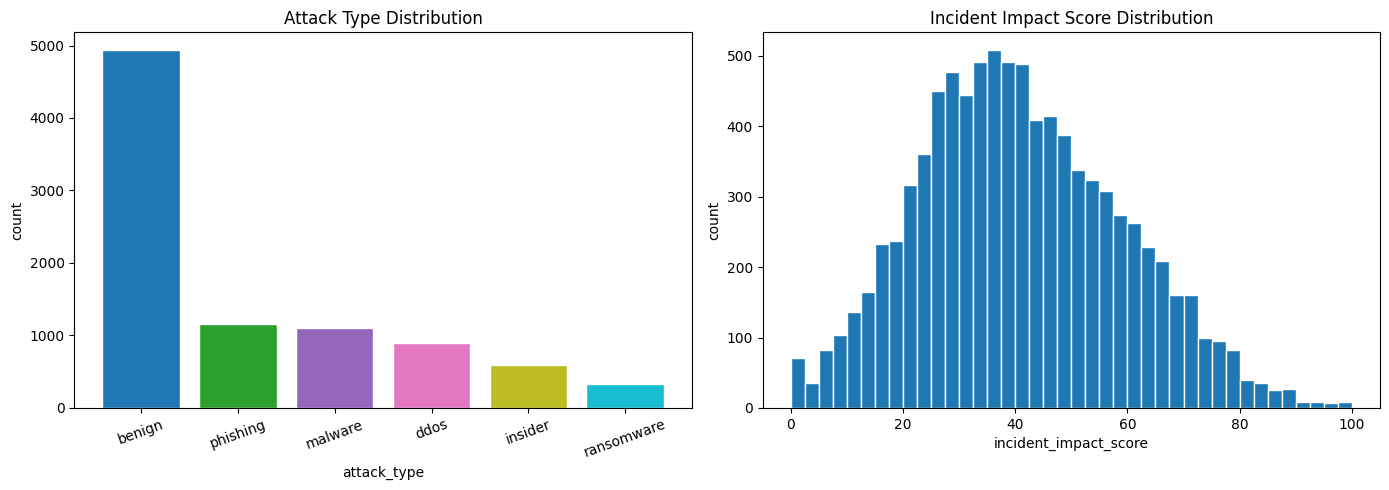

In [11]:
# --- Class distribution + target distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df["attack_type"].value_counts()
classes = class_counts.index.tolist()
counts = class_counts.values

cmap = plt.cm.get_cmap("tab10", len(classes))
colors = [cmap(i) for i in range(len(classes))]

axes[0].bar(classes, counts, color=colors, edgecolor="white")
axes[0].set_title("Attack Type Distribution")
axes[0].set_xlabel("attack_type")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=20)

axes[1].hist(df["incident_impact_score"].values, bins=40, edgecolor="white")
axes[1].set_title("Incident Impact Score Distribution")
axes[1].set_xlabel("incident_impact_score")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()


## 2) Preprocessing / feature engineering

In [12]:
# --- Feature engineering ---
df_fe = df.copy()

# Time-derived features (defensive fill)
df_fe["hour_utc"] = df_fe["timestamp_utc"].dt.hour.astype("Int64")
df_fe["dayofweek_utc"] = df_fe["timestamp_utc"].dt.dayofweek.astype("Int64")
for c in ["hour_utc", "dayofweek_utc"]:
    df_fe[c] = df_fe[c].fillna(int(df_fe[c].median()))

# bool -> int
for c in df_fe.select_dtypes(include=["bool"]).columns:
    df_fe[c] = df_fe[c].astype(np.int8)

# Targets
y_reg = df_fe["incident_impact_score"].astype(np.float32)
y_clf = df_fe["attack_type"].astype(str)

# Drop non-features
drop_cols = ["record_id", "timestamp_utc"]
df_fe = df_fe.drop(columns=[c for c in drop_cols if c in df_fe.columns])

# Regression features: drop both targets
X_reg = df_fe.drop(columns=["incident_impact_score", "attack_type"])

# Classification features: drop impact score and label
X_clf = df_fe.drop(columns=["incident_impact_score", "attack_type"])

print("X_reg:", X_reg.shape, "y_reg:", y_reg.shape)
print("X_clf:", X_clf.shape, "y_clf:", y_clf.shape)


X_reg: (9000, 360) y_reg: (9000,)
X_clf: (9000, 360) y_clf: (9000,)


## 3) Train/test split (stratified by class)

In [13]:
# We stratify the split by attack_type so all classes appear similarly in train/test.
Xr_train, Xr_test, yr_train, yr_test, at_train, at_test = train_test_split(
    X_reg, y_reg, y_clf,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print("Regression train/test:", Xr_train.shape, Xr_test.shape)
print("Classification train/test:", Xc_train.shape, Xc_test.shape)


Regression train/test: (7200, 360) (1800, 360)
Classification train/test: (7200, 360) (1800, 360)


## 4) PCA view of the feature space (colored by class)

/tmp/ipykernel_225/2733469456.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(classes))


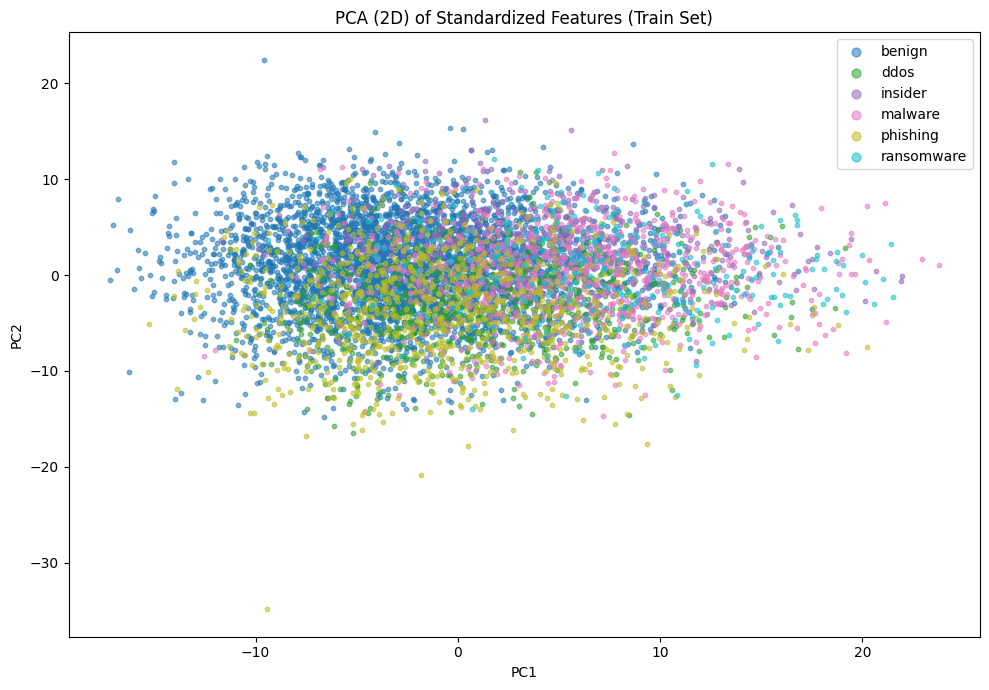

Explained variance ratio: [0.11347968 0.070666  ]


In [14]:
# Standardize for PCA (fit on train)
scaler_pca = StandardScaler()
Z_train = scaler_pca.fit_transform(Xc_train)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
P = pca.fit_transform(Z_train)

classes = sorted(yc_train.unique())
cmap = plt.cm.get_cmap("tab10", len(classes))
color_map = {c: cmap(i) for i, c in enumerate(classes)}

plt.figure(figsize=(10, 7))
for c in classes:
    idx = (yc_train.values == c)
    plt.scatter(P[idx, 0], P[idx, 1], s=10, alpha=0.55, color=color_map[c], label=c)

plt.title("PCA (2D) of Standardized Features (Train Set)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=2, frameon=True)
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


# Regression Ensembles

## 5) Regression models: bagging, boosting, stacking

In [8]:
def eval_reg(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        "model": name,
        "R2": float(r2_score(y_test, pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_test, pred))),
        "MAE": float(mean_absolute_error(y_test, pred)),
        "pred": pred,
        "est": model
    }

# For tree ensembles we can use raw features.
# For linear baselines (Ridge), scale features.
ridge = Pipeline([("scaler", StandardScaler()), ("m", Ridge(alpha=30.0, random_state=RANDOM_STATE))])

tree_base = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)

bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    n_estimators=N_EST_BAG,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf = RandomForestRegressor(
    n_estimators=N_EST_RF,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

et = ExtraTreesRegressor(
    n_estimators=N_EST_RF,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE),
    n_estimators=250 if not SPEED_MODE else 150,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)

gbr = GradientBoostingRegressor(
    n_estimators=350 if not SPEED_MODE else 200,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

hgb = HistGradientBoostingRegressor(
    learning_rate=0.06,
    max_depth=6,
    max_iter=350 if not SPEED_MODE else 220,
    random_state=RANDOM_STATE
)

# Stacking (mix linear + tree + boosting)
stack_reg = StackingRegressor(
    estimators=[
        ("ridge", ridge),
        ("rf", rf),
        ("hgb", hgb),
    ],
    final_estimator=Ridge(alpha=10.0, random_state=RANDOM_STATE),
    passthrough=False,
    n_jobs=-1
)

reg_models = [
    ("Ridge (scaled linear baseline)", ridge),
    ("DecisionTreeRegressor (single tree)", tree_base),
    ("BaggingRegressor (trees)", bag),
    ("RandomForestRegressor", rf),
    ("ExtraTreesRegressor", et),
    ("AdaBoostRegressor", ada),
    ("GradientBoostingRegressor", gbr),
    ("HistGradientBoostingRegressor", hgb),
    ("StackingRegressor (ridge+rf+hgb)", stack_reg),
]

reg_results = []
for name, m in reg_models:
    reg_results.append(eval_reg(name, m, Xr_train, Xr_test, yr_train, yr_test))

reg_df = pd.DataFrame([{k: v for k, v in r.items() if k in ["model","R2","RMSE","MAE"]} for r in reg_results])
reg_df = reg_df.sort_values("R2", ascending=False).reset_index(drop=True)
display(reg_df)


,model,R2,RMSE,MAE
0,StackingRegressor (ridge+rf+hgb),0.782948,8.530433,6.795155
1,Ridge (scaled linear baseline),0.777583,8.635223,6.846284
2,GradientBoostingRegressor,0.772021,8.742532,6.964366
3,RandomForestRegressor,0.769536,8.790036,7.036494
4,HistGradientBoostingRegressor,0.769258,8.795345,6.932204
5,ExtraTreesRegressor,0.765313,8.870203,7.096444
6,BaggingRegressor (trees),0.763114,8.911666,7.078406
7,AdaBoostRegressor,0.732620,9.467909,7.605020
8,DecisionTreeRegressor (single tree),0.671256,10.498294,8.274673


## 6) Regression performance plots (multi-color)

/tmp/ipykernel_225/2881695925.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(models_order))


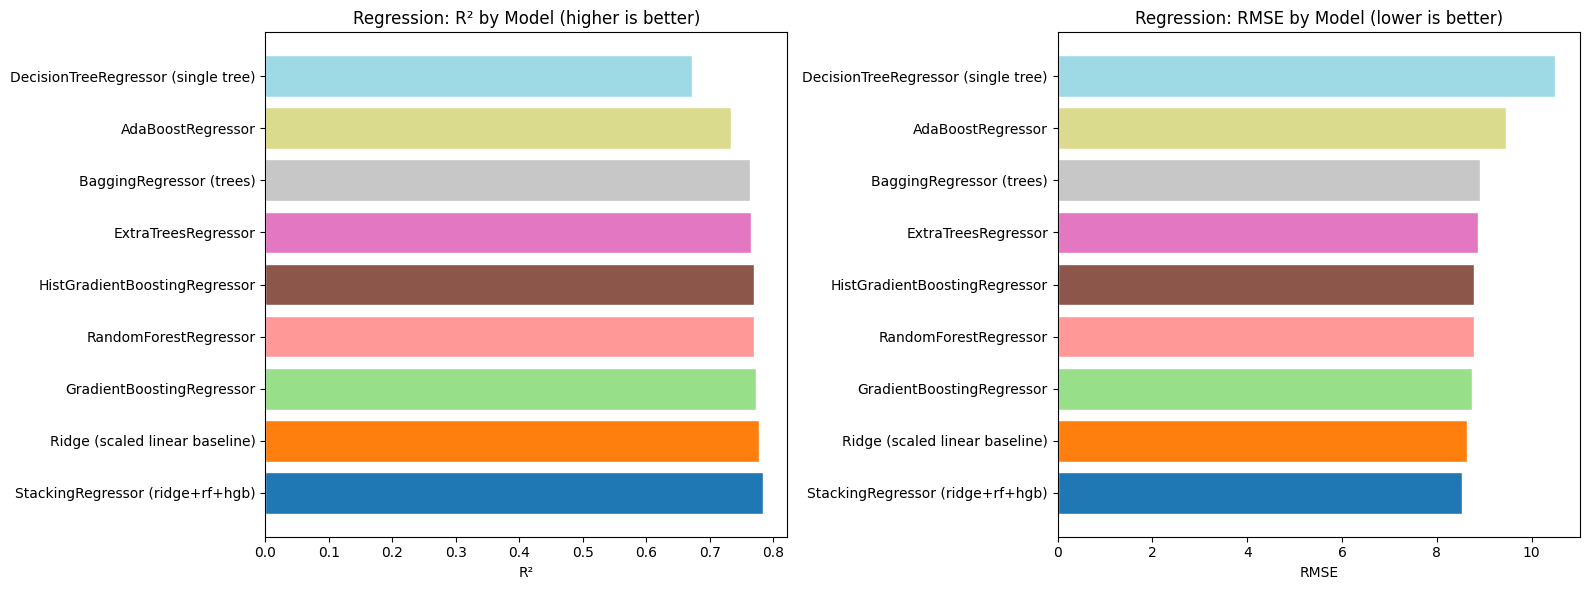

In [15]:
models_order = reg_df["model"].tolist()
r2_vals = reg_df["R2"].values
rmse_vals = reg_df["RMSE"].values

cmap = plt.cm.get_cmap("tab20", len(models_order))
colors = [cmap(i) for i in range(len(models_order))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(models_order, r2_vals, color=colors, edgecolor="white")
axes[0].set_title("Regression: R² by Model (higher is better)")
axes[0].set_xlabel("R²")

axes[1].barh(models_order, rmse_vals, color=colors, edgecolor="white")
axes[1].set_title("Regression: RMSE by Model (lower is better)")
axes[1].set_xlabel("RMSE")

plt.tight_layout()
plt.show()


## 7) Best regression model diagnostics (colored by class)

Best regression model: StackingRegressor (ridge+rf+hgb)
R2: 0.7829483289124494 RMSE: 8.530432968047924


/tmp/ipykernel_225/362372172.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(classes))


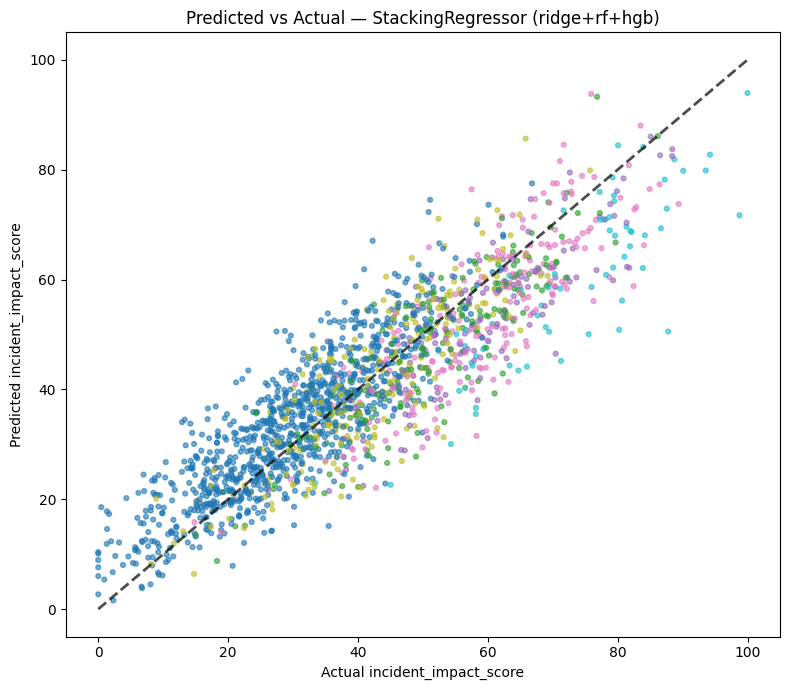

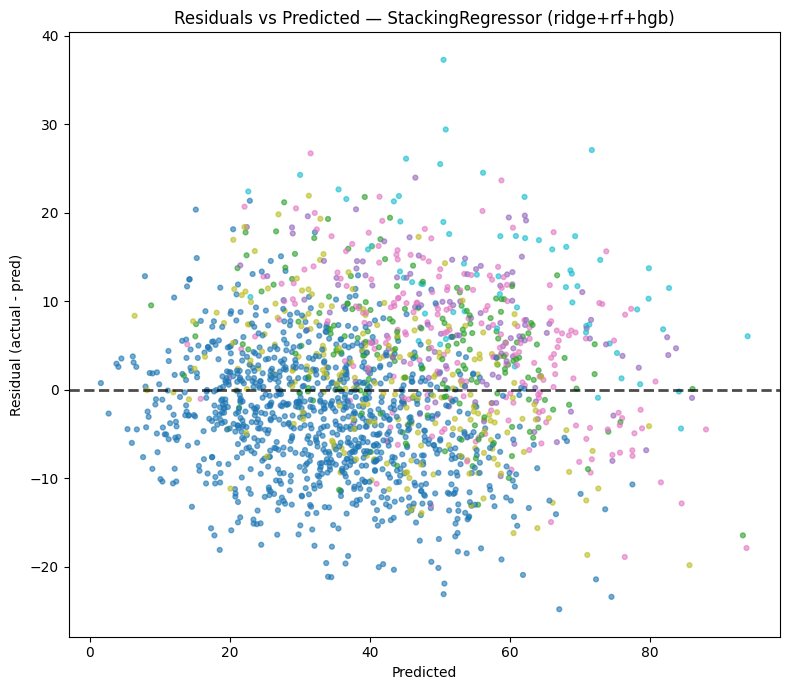

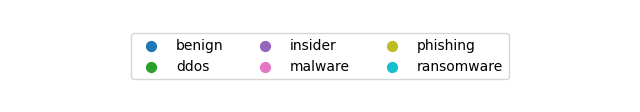

In [16]:
best_reg_name = reg_df.loc[0, "model"]
best_reg = next(r for r in reg_results if r["model"] == best_reg_name)
pred = best_reg["pred"]

print("Best regression model:", best_reg_name)
print("R2:", r2_score(yr_test, pred), "RMSE:", np.sqrt(mean_squared_error(yr_test, pred)))

# Color points by attack type
classes = sorted(at_test.unique())
cmap = plt.cm.get_cmap("tab10", len(classes))
color_map = {c: cmap(i) for i, c in enumerate(classes)}
point_colors = [color_map[c] for c in at_test.values]

# Predicted vs Actual
plt.figure(figsize=(8, 7))
plt.scatter(yr_test, pred, s=12, alpha=0.6, c=point_colors)
mn = float(min(yr_test.min(), pred.min()))
mx = float(max(yr_test.max(), pred.max()))
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=2, color="black", alpha=0.7)
plt.title(f"Predicted vs Actual — {best_reg_name}")
plt.xlabel("Actual incident_impact_score")
plt.ylabel("Predicted incident_impact_score")
plt.tight_layout()
plt.show()

# Residuals vs Predicted
res = yr_test.values - pred
plt.figure(figsize=(8, 7))
plt.scatter(pred, res, s=12, alpha=0.6, c=point_colors)
plt.axhline(0, linestyle="--", linewidth=2, color="black", alpha=0.7)
plt.title(f"Residuals vs Predicted — {best_reg_name}")
plt.xlabel("Predicted")
plt.ylabel("Residual (actual - pred)")
plt.tight_layout()
plt.show()

# Legend
plt.figure(figsize=(8, 1.2))
for c in classes:
    plt.scatter([], [], color=color_map[c], label=c, s=50)
plt.legend(ncol=3, frameon=True, loc="center")
plt.axis("off")
plt.show()


## 8) Feature importance (tree ensemble)

/tmp/ipykernel_225/3868896658.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("viridis", top_k)


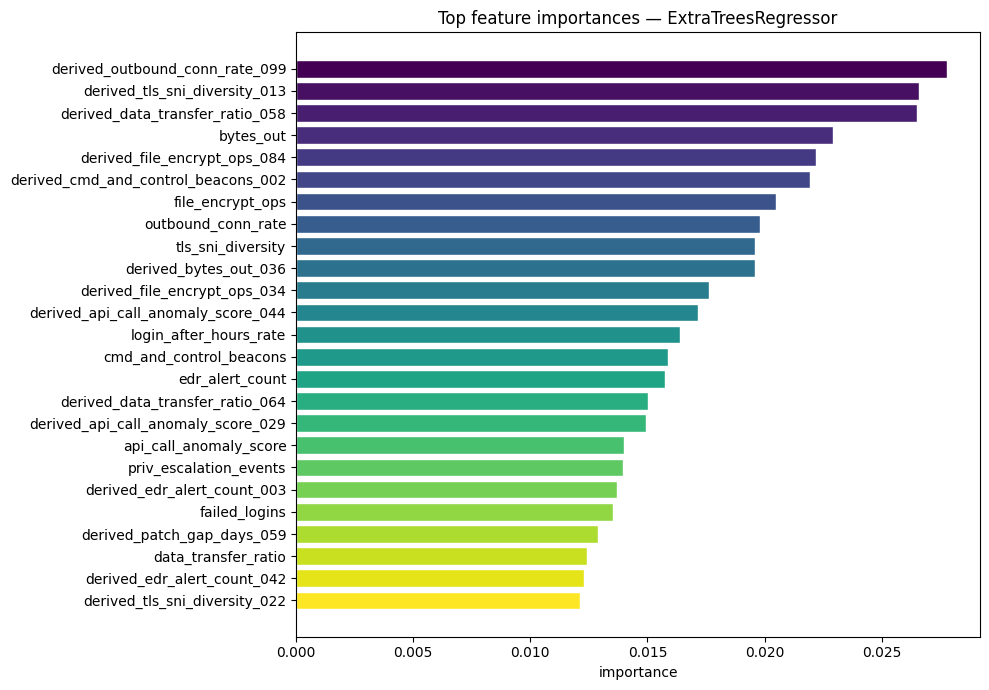

In [17]:
# Many ensembles expose feature_importances_. If best model doesn't, pick the best among those that do.
feature_names = X_reg.columns.tolist()

def top_feature_importance(est, title, top_k=25):
    imp = getattr(est, "feature_importances_", None)
    if imp is None:
        print("No feature_importances_ for:", title)
        return
    idx = np.argsort(imp)[-top_k:][::-1]
    feats = [feature_names[i] for i in idx]
    vals = imp[idx]

    plt.figure(figsize=(10, 7))
    # multi-color bars
    cmap = plt.cm.get_cmap("viridis", top_k)
    colors = [cmap(i) for i in range(top_k)]
    plt.barh(feats[::-1], vals[::-1], color=colors[::-1], edgecolor="white")
    plt.title(title)
    plt.xlabel("importance")
    plt.tight_layout()
    plt.show()

# choose an estimator for importance
importance_candidate = None
for name in ["ExtraTreesRegressor", "RandomForestRegressor", "HistGradientBoostingRegressor", "GradientBoostingRegressor"]:
    cand = next((r for r in reg_results if r["model"].startswith(name)), None)
    if cand is not None and hasattr(cand["est"], "feature_importances_"):
        importance_candidate = cand
        break

if importance_candidate is None:
    print("No tree-based importance candidate found.")
else:
    top_feature_importance(importance_candidate["est"], f"Top feature importances — {importance_candidate['model']}", top_k=25)


## 9) Bagging sweep (n_estimators vs RMSE)

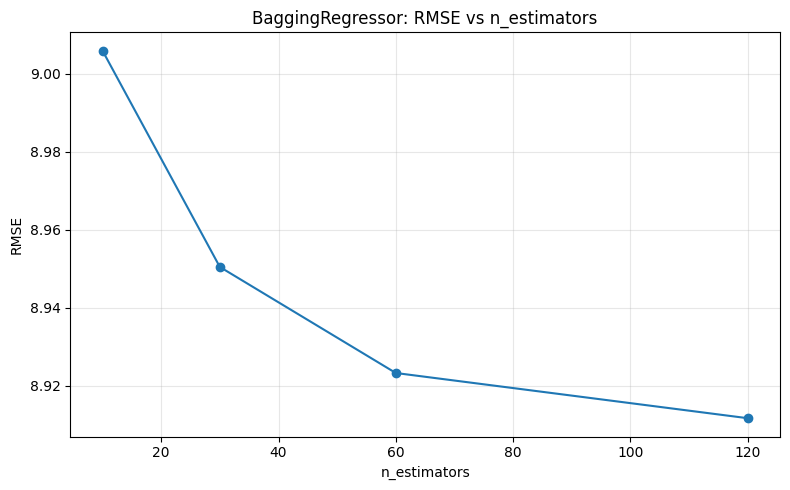

In [18]:
# Keep sweep small for runtime
n_list = [10, 30, 60, 120] if SPEED_MODE else [10, 50, 100, 200]

rmse_list = []
for n_est in n_list:
    m = BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
        n_estimators=n_est,
        max_samples=0.8,
        max_features=0.8,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    m.fit(Xr_train, yr_train)
    p = m.predict(Xr_test)
    rmse_list.append(np.sqrt(mean_squared_error(yr_test, p)))

plt.figure(figsize=(8, 5))
plt.plot(n_list, rmse_list, marker="o")
plt.title("BaggingRegressor: RMSE vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10) Boosting sweep (learning_rate vs RMSE)

In [ ]:
lr_list = [0.01, 0.03, 0.05, 0.08, 0.12] if SPEED_MODE else [0.01, 0.03, 0.05, 0.08, 0.12, 0.18]
rmse_lr = []

for lr in lr_list:
    m = HistGradientBoostingRegressor(
        learning_rate=lr,
        max_depth=6,
        max_iter=220 if SPEED_MODE else 350,
        random_state=RANDOM_STATE
    )
    m.fit(Xr_train, yr_train)
    p = m.predict(Xr_test)
    rmse_lr.append(np.sqrt(mean_squared_error(yr_test, p)))

plt.figure(figsize=(8, 5))
plt.plot(lr_list, rmse_lr, marker="o")
plt.title("HistGradientBoostingRegressor: RMSE vs learning_rate")
plt.xlabel("learning_rate")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Classification Ensembles

## 11) Classification models: bagging, boosting, stacking

In [ ]:
def eval_clf(name, model, X_train, X_test, y_train, y_test, labels_sorted):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)
        ll = float(log_loss(y_test, proba, labels=labels_sorted))
    else:
        proba = None
        ll = np.nan

    return {
        "model": name,
        "accuracy": float(accuracy_score(y_test, pred)),
        "macro_f1": float(f1_score(y_test, pred, average="macro")),
        "weighted_f1": float(f1_score(y_test, pred, average="weighted")),
        "log_loss": ll,
        "pred": pred,
        "proba": proba,
        "est": model
    }

labels_sorted = sorted(yc_train.unique())

# Logistic regression (scaled) baseline
lr_base = Pipeline([
    ("scaler", StandardScaler()),
    ("m", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        penalty="l2",
        C=0.35,
        max_iter=600
    ))
])

dt_clf = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)

bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    n_estimators=N_EST_BAG,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_clf = RandomForestClassifier(
    n_estimators=N_EST_RF,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

et_clf = ExtraTreesClassifier(
    n_estimators=N_EST_RF,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
    n_estimators=250 if not SPEED_MODE else 150,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)

gbrt_clf = GradientBoostingClassifier(
    n_estimators=350 if not SPEED_MODE else 200,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE
)

hgb_clf = HistGradientBoostingClassifier(
    learning_rate=0.06,
    max_depth=6,
    max_iter=350 if not SPEED_MODE else 220,
    random_state=RANDOM_STATE
)

# StackingClassifier: include a scaled LR plus tree ensembles
stack_clf = StackingClassifier(
    estimators=[
        ("lr", lr_base),
        ("rf", rf_clf),
        ("hgb", hgb_clf),
    ],
    final_estimator=LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        penalty="l2",
        C=1.0,
        max_iter=600
    ),
    passthrough=False,
    n_jobs=-1
)

clf_models = [
    ("LogisticRegression (scaled baseline)", lr_base),
    ("DecisionTreeClassifier (single tree)", dt_clf),
    ("BaggingClassifier (trees)", bag_clf),
    ("RandomForestClassifier", rf_clf),
    ("ExtraTreesClassifier", et_clf),
    ("AdaBoostClassifier", ada_clf),
    ("GradientBoostingClassifier", gbrt_clf),
    ("HistGradientBoostingClassifier", hgb_clf),
    ("StackingClassifier (lr+rf+hgb)", stack_clf),
]

clf_results = []
for name, m in clf_models:
    clf_results.append(eval_clf(name, m, Xc_train, Xc_test, yc_train, yc_test, labels_sorted))

clf_df = pd.DataFrame([{k: v for k, v in r.items() if k in ["model","accuracy","macro_f1","weighted_f1","log_loss"]} for r in clf_results])
clf_df = clf_df.sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(clf_df)


## 12) Classification performance plots (multi-color)

In [ ]:
models_order = clf_df["model"].tolist()
acc = clf_df["accuracy"].values
mf1 = clf_df["macro_f1"].values

cmap = plt.cm.get_cmap("tab20", len(models_order))
colors = [cmap(i) for i in range(len(models_order))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(models_order, acc, color=colors, edgecolor="white")
axes[0].set_title("Classification: Accuracy by Model")
axes[0].set_xlabel("Accuracy")

axes[1].barh(models_order, mf1, color=colors, edgecolor="white")
axes[1].set_title("Classification: Macro-F1 by Model (primary)")
axes[1].set_xlabel("Macro-F1")

plt.tight_layout()
plt.show()


## 13) Confusion matrix for best classifier (heatmap + annotations)

In [ ]:
best_clf_name = clf_df.loc[0, "model"]
best_clf = next(r for r in clf_results if r["model"] == best_clf_name)

print("Best classifier:", best_clf_name)
print("Accuracy:", best_clf["accuracy"], "Macro-F1:", best_clf["macro_f1"], "Weighted-F1:", best_clf["weighted_f1"])

labels = labels_sorted
cm = confusion_matrix(yc_test, best_clf["pred"], labels=labels)

plt.figure(figsize=(8.5, 7.5))
plt.imshow(cm, interpolation="nearest", cmap="viridis")
plt.title(f"Confusion Matrix — {best_clf_name}")
plt.colorbar(label="count")
tick = np.arange(len(labels))
plt.xticks(tick, labels, rotation=45, ha="right")
plt.yticks(tick, labels)

thresh = cm.max() * 0.55
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=9)

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


## 14) Per-class F1 (multi-color bar plot)

In [ ]:
rep = classification_report(yc_test, best_clf["pred"], labels=labels, output_dict=True, zero_division=0)
per_class_f1 = {k: rep[k]["f1-score"] for k in labels}

cmap = plt.cm.get_cmap("tab10", len(labels))
colors = [cmap(i) for i in range(len(labels))]

plt.figure(figsize=(10, 5))
plt.bar(list(per_class_f1.keys()), list(per_class_f1.values()), color=colors, edgecolor="white")
plt.title(f"Per-class F1 — {best_clf_name}")
plt.xlabel("class")
plt.ylabel("F1-score")
plt.ylim(0, 1.0)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(pd.DataFrame(rep).T.loc[labels + ["accuracy", "macro avg", "weighted avg"]])


## 15) Feature importance (best tree classifier)

In [ ]:
feature_names = X_clf.columns.tolist()

def plot_top_importances(est, title, top_k=25):
    if not hasattr(est, "feature_importances_"):
        print("No feature_importances_ for:", title)
        return
    imp = est.feature_importances_
    idx = np.argsort(imp)[-top_k:][::-1]
    feats = [feature_names[i] for i in idx]
    vals = imp[idx]

    plt.figure(figsize=(10, 7))
    cmap = plt.cm.get_cmap("plasma", top_k)
    colors = [cmap(i) for i in range(top_k)]
    plt.barh(feats[::-1], vals[::-1], color=colors[::-1], edgecolor="white")
    plt.title(title)
    plt.xlabel("importance")
    plt.tight_layout()
    plt.show()

# choose best among tree-based models for importances (not necessarily overall best)
tree_candidates = [r for r in clf_results if hasattr(r["est"], "feature_importances_")]
if len(tree_candidates) == 0:
    print("No tree models with feature importances found.")
else:
    # pick the one with best macro_f1 among candidates
    best_tree = max(tree_candidates, key=lambda d: d["macro_f1"])
    plot_top_importances(best_tree["est"], f"Top feature importances — {best_tree['model']}", top_k=25)


## 16) Bagging sweep (n_estimators vs Macro-F1)

In [ ]:
n_list = [10, 30, 60, 120] if SPEED_MODE else [10, 50, 100, 200]
mf1_list = []

for n_est in n_list:
    m = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
        n_estimators=n_est,
        max_samples=0.8,
        max_features=0.8,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    m.fit(Xc_train, yc_train)
    p = m.predict(Xc_test)
    mf1_list.append(f1_score(yc_test, p, average="macro"))

plt.figure(figsize=(8, 5))
plt.plot(n_list, mf1_list, marker="o")
plt.title("BaggingClassifier: Macro-F1 vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Macro-F1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 17) Boosting sweep (learning_rate vs Macro-F1)

In [ ]:
lr_list = [0.01, 0.03, 0.05, 0.08, 0.12] if SPEED_MODE else [0.01, 0.03, 0.05, 0.08, 0.12, 0.18]
mf1_lr = []

for lr in lr_list:
    m = HistGradientBoostingClassifier(
        learning_rate=lr,
        max_depth=6,
        max_iter=220 if SPEED_MODE else 350,
        random_state=RANDOM_STATE
    )
    m.fit(Xc_train, yc_train)
    p = m.predict(Xc_test)
    mf1_lr.append(f1_score(yc_test, p, average="macro"))

plt.figure(figsize=(8, 5))
plt.plot(lr_list, mf1_lr, marker="o")
plt.title("HistGradientBoostingClassifier: Macro-F1 vs learning_rate")
plt.xlabel("learning_rate")
plt.ylabel("Macro-F1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Wrap-up

You now have:
- Regression ensembles + diagnostics + feature importances
- Classification ensembles + confusion matrix + per-class F1 + feature importances
- Hyperparameter sweeps showing how ensemble size and learning_rate affect performance

If you need higher scores:
- Tune depth / leaf sizes for RF/ET
- Increase max_iter for HGB
- Use larger n_estimators (with patience)
- Consider calibrating probabilities for classification (optional)
